# NutriPredict Congo: Analyse Exploratoire des Données (EDA)
**Auteur :** MPOY Schekina Lutte-de-vie  
**Date :** 08 juillet 2026  
**Notebook :** 03 / 05 — Analyse exploratoire  

---

## Objectif de ce notebook

Comprendre la distribution du stunting (retard de croissance)
selon les facteurs socio-démographiques disponibles dans le
dataset congo_clean.csv produit en Phase 2.

Questions auxquelles ce notebook répond :
1. Quelle est la distribution globale du stunting ?
2. Le stunting varie-t-il selon le milieu (urbain/rural) ?
3. Quel est le lien avec le niveau de richesse du ménage ?
4. L'accès à l'eau et à l'électricité joue-t-il un rôle ?
5. Y a-t-il des différences selon le sexe et l'âge de l'enfant ?
6. Le rang de naissance influence-t-il le risque ?

## Source des données
* Dataset : data/processed/congo_clean.csv
* Produit par : notebook 02_nettoyage_fusion.ipynb
* Lignes : 4 475 enfants mesurés
* Colonnes : 16 variables

## 1. Imports et chargement des données

On charge directement le fichier congo_clean.csv produit
en Phase 2, pas les fichiers DHS bruts. C'est l'avantage
d'avoir exporté un dataset propre : les notebooks suivants
n'ont plus besoin de refaire tout le nettoyage.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os  
import warnings
warnings.filterwarnings("ignore")

In [2]:
# configuration du style glabal des graphiques
sns.set_theme(style="whitegrid",palette="muted")
plt.rcParams["figure.dpi"]=120
plt.rcParams["font.family"]="sans-serif"

In [3]:
# Chargement du dataset 
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(),".."))
CHEMIN_DATA = os.path.join(BASE_DIR,"data","processed","congo_clean.csv")

df=pd.read_csv(CHEMIN_DATA)

print(f"Dataset chargé : {df.shape[0]} lignes,  {df.shape[1]} colonnes ")
print("\n == Aperçu du dataset == ")
print(df.sample(5))
print("\n == types des colonnes ==")
print(df.info())

Dataset chargé : 4475 lignes,  16 colonnes 

 == Aperçu du dataset == 
      v001  v002  hw70  hw71  hw72  b4   b8  bord cle_menage  hv025  hv270  \
1362   106    26 -3.08 -2.35 -1.08   2  1.0     2     106_26      2      1   
3619   283     8 -0.48 -1.23 -1.15   2  0.0    11      283_8      2      1   
4066   341    18 -0.70  1.81  2.77   1  1.0     4     341_18      1      5   
2226   177    11 -1.27 -0.35  0.65   1  4.0     5     177_11      2      1   
176     12    20 -0.24 -1.27 -1.66   2  3.0     3      12_20      2      2   

      hv201  hv205  hv206  hv219  stunting  
1362     96     23      0      1         1  
3619     43     23      0      2         0  
4066     12     11      1      1         0  
2226     43     31      0      1         0  
176      21     23      0      1         0  

 == types des colonnes ==
<class 'pandas.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      ---------

## 2. Recodage des variables catégorielles

Les variables socio-démographiques sont stockées sous forme
de codes numériques (ex: hv025 = 1 ou 2). Pour que les
graphiques soient lisibles directement, on crée des versions
textuelles de ces variables.

On ne modifie pas les colonnes originales, on ajoute de
nouvelles colonnes avec le suffixe _label. Les colonnes
numériques originales restent disponibles pour le ML en Phase 4.

In [4]:
# Recodage des variables catégorielles en labels lisibles

#
df["hv025_label"] = df["hv025"].map({1:"Urbain",2:"Rural"})

df["hv270_label"] = df["hv270"].map({
    1:"Q1-très pauvre",
    2:"Q2-pauvre",
    3:"Q3-moyen",
    4:"Q4-riche",
    5:"Q5-très riche"
})

#Accès à l'electricité
df["hv206_label"] = df["hv206"].map({0:"Sans électricité",1:"Avec électricité",9:None})

# Sexe de l'enfant
df["b4_label"] = df["b4"].map({1:"Masculin",2:"Féminin"})

# Sexe du chef de famille
df["hv219_label"] = df["hv219"].map({1:"Homme",2:"Femme"})


# Vérification 1
print("=== Vérification des recodage ===")
print(f"hv025_labels :{df["hv025_label"].value_counts().to_dict()}")
print(f"hv270_label : {df['hv270_label'].value_counts().to_dict()}")
print(f"hv206_label : {df['hv206_label'].value_counts().to_dict()}")
print(f"b4_label    : {df['b4_label'].value_counts().to_dict()}")
print(f"hv219_label : {df['hv219_label'].value_counts().to_dict()}")

#Vérification 2
print("\n=== Vérification qu'aucun code n'est resté non mappé ===")
for col in ['hv025_label', 'hv270_label', 'hv206_label', 'b4_label', 'hv219_label']:
    nan_count = df[col].isna().sum()
    if nan_count > 0:
        print(f" {col} : {nan_count} valeurs non mappées,devenu NaN")
    else:
        print(f" {col} : aucune valeur non mappée")



=== Vérification des recodage ===
hv025_labels :{'Rural': 3335, 'Urbain': 1140}
hv270_label : {'Q1-très pauvre': 1997, 'Q2-pauvre': 1243, 'Q3-moyen': 500, 'Q4-riche': 423, 'Q5-très riche': 312}
hv206_label : {'Sans électricité': 3531, 'Avec électricité': 943}
b4_label    : {'Masculin': 2283, 'Féminin': 2192}
hv219_label : {'Homme': 3695, 'Femme': 780}

=== Vérification qu'aucun code n'est resté non mappé ===
 hv025_label : aucune valeur non mappée
 hv270_label : aucune valeur non mappée
 hv206_label : 1 valeurs non mappées,devenu NaN
 b4_label : aucune valeur non mappée
 hv219_label : aucune valeur non mappée


## 3. Distribution globale du stunting

Première visualisation: quelle proportion d'enfants présente
un retard de croissance dans l'échantillon 
Congo 2011-12 ?

C'est le point de départ de toute l'analyse, on pose le
constat global avant d'explorer les facteurs explicatifs.

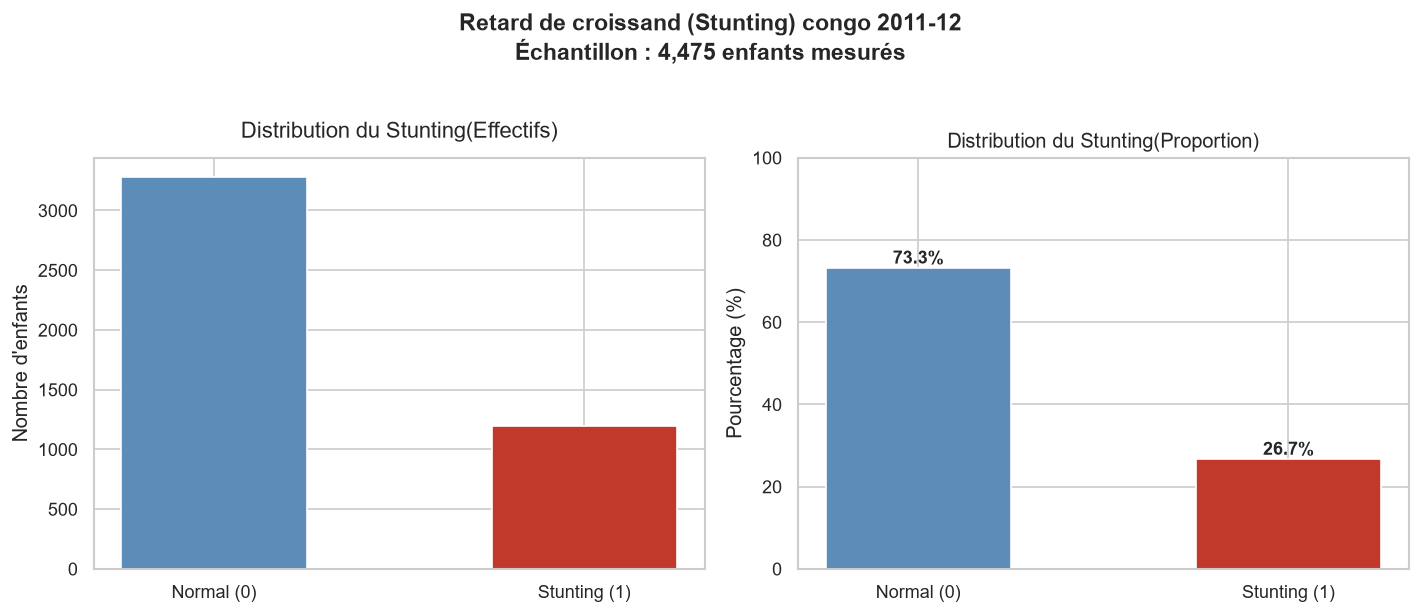

Graphique sauvegardé avec succès dans outputs


In [5]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

# Graphique gauche : Comptage brut
counts = df["stunting"].value_counts().sort_index()
labels =["Normal (0)","Stunting (1)"]
colors = ['#5B8DB8', '#C0392B']

axes[0].bar(labels,counts.values,color=colors,width =0.5, edgecolor = "white")
axes[0].set_title("Distribution du Stunting(Effectifs)", fontsize=13,pad=12)
axes[0].set_ylabel("Nombre d\'enfants")
axes[0].set_xlabel("")

# Graphique droite : proportions
proportions = counts.values/counts.values.sum()*100
axes[1].bar(labels, proportions,color=colors,width=0.5,edgecolor="white")
axes[1].set_title("Distribution du Stunting(Proportion)")
axes[1].set_ylabel("Pourcentage (%)")
axes[1].set_xlabel("")
axes[1].set_ylim(0,100)
for i,v in enumerate(proportions):
    axes[1].text(i,v+1,f"{v:.1f}%", ha = "center", fontsize=11,fontweight="bold")

fig.suptitle(
    "Retard de croissand (Stunting) congo 2011-12\n"
    f"Échantillon : {len(df):,} enfants mesurés",
    fontsize = 14,fontweight = "bold", y=1.02
)

plt.tight_layout()

#Sauvegarde  des outputs
 
OUTPUT_DIR = os.path.join(BASE_DIR,"outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR,"01_distribution_stunting.png"),dpi=150, bbox_inches='tight')

plt.show()
print("Graphique sauvegardé avec succès dans outputs")

## 4. Stunting par milieu de résidence (urbain / rural)

L'écart urbain/rural est l'une des hypothèses centrales
du projet : les enfants en zone rurale sont-ils
significativement plus touchés par le retard de croissance
que ceux en zone urbaine ?

C'est aussi une variable directement liée à l'axe
agriculture/développement rural du PND 2022-2026.

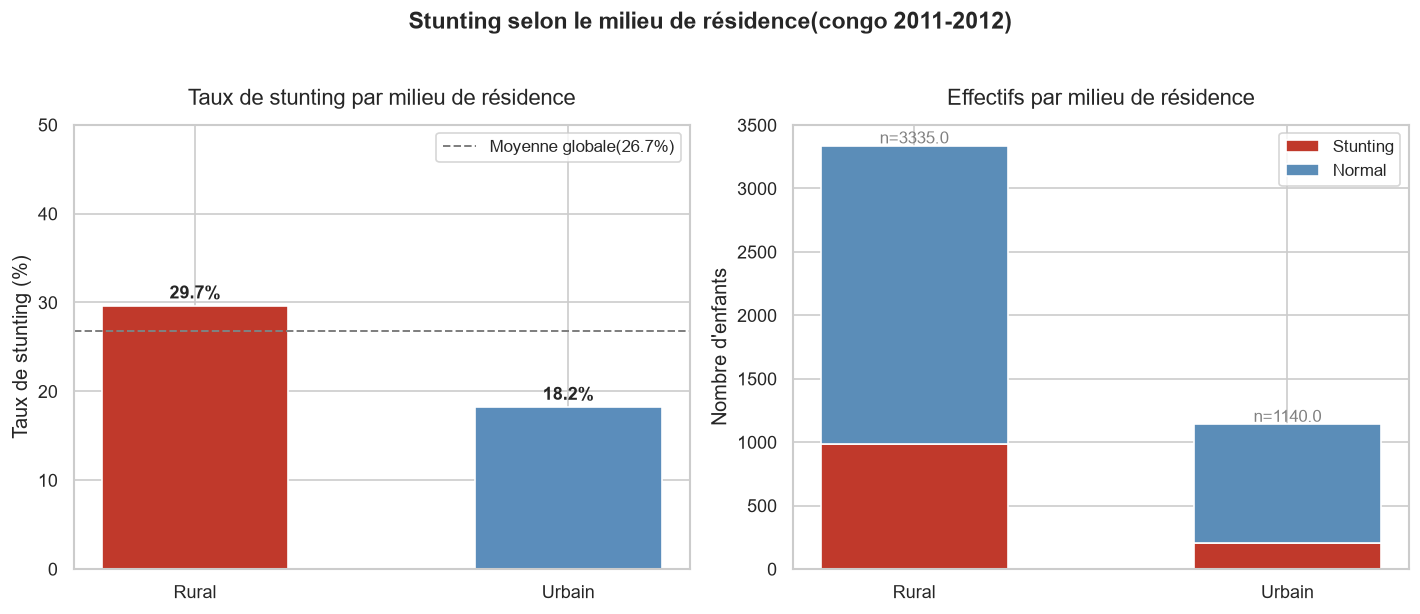

 Graphique sauvegardé

=== Résumé numérique ===
             stunting  total  taux
hv025_label                       
Rural             989   3335  29.7
Urbain            208   1140  18.2


In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

# Calcul des taux de stunting par milieu
taux_milieu = (df.groupby("hv025_label")["stunting"]
               .agg(["sum","count"])
               .rename(columns={"sum":"stunting","count":"total"})
               )
taux_milieu["taux"] = taux_milieu["stunting"]/taux_milieu["total"]*100
taux_milieu = taux_milieu.sort_values("taux",ascending=False)

# Graphique gauche : Taux de stunting par milieu
colors_milieu = ["#C0392B"if t>25 else "#5B8DBB"
                 for t in taux_milieu["taux"]]

axes[0].bar(taux_milieu.index, taux_milieu["taux"], color = colors_milieu,width = 0.5,edgecolor = "white")
axes[0].set_title("Taux de stunting par milieu de résidence",
                  fontsize=13,pad=12)
axes[0].set_ylabel("Taux de stunting (%)")
axes[0].set_ylim(0,50)
axes[0].axhline(y=df["stunting"].mean()*100,
                color="grey",linestyle = "--",linewidth=1.2,
                label=f"Moyenne globale({df["stunting"].mean()*100:.1f}%)")
axes[0].legend(fontsize=10)
for i,(idx,row) in enumerate(taux_milieu.iterrows()):
    axes[0].text(i,row["taux"]+0.8,f"{row["taux"]:.1f}%",
                 ha="center",fontsize = 11,fontweight="bold")
    

# Graphique droite : effectifs par milieu
axes[1].bar(taux_milieu.index,taux_milieu["stunting"], color="#C0392B",
            width=0.5,label="Stunting",edgecolor="white")
axes[1].bar(taux_milieu.index,taux_milieu["total"]-taux_milieu["stunting"],bottom =taux_milieu["stunting"],
            color = "#5B8DB8", width=0.5, label="Normal",edgecolor="white")

axes[1].set_title("Effectifs par milieu de résidence", fontsize=13,
                  pad=12)
axes[1].set_ylabel("Nombre d\'enfants")
axes[1].legend(fontsize=10)

for i , (idx, row) in enumerate(taux_milieu.iterrows()):
    axes[1].text(i,row["total"]+20,f"n={row["total"]}",ha="center",fontsize=10,
                 color="grey")

fig.suptitle("Stunting selon le milieu de résidence(congo 2011-2012)",
             fontsize=14,fontweight="bold",y=1.02
             )
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"02_stunting_milieu.png"),dpi=150,bbox_inches="tight")

plt.show()
print(" Graphique sauvegardé")


#Résumé numérique 
print("\n=== Résumé numérique ===")
print(taux_milieu[["stunting","total","taux"]].round(1))





## 5. Stunting par quintile de richesse

L'écart urbain/rural (29.7% vs 18.2%) est documenté.
On examine maintenant si le niveau de richesse du ménage
suit la même logique : plus le ménage est pauvre,
plus le risque de stunting est élevé.

Le wealth index DHS (hv270) est un indicateur composite
construit à partir des biens possédés par le ménage
(électroménager, matériaux de construction, véhicules)
, pas du revenu déclaré, difficile à mesurer en enquête.

Q1 = quintile le plus pauvre (20% les plus pauvres)
Q5 = quintile le plus riche (20% les plus riches)

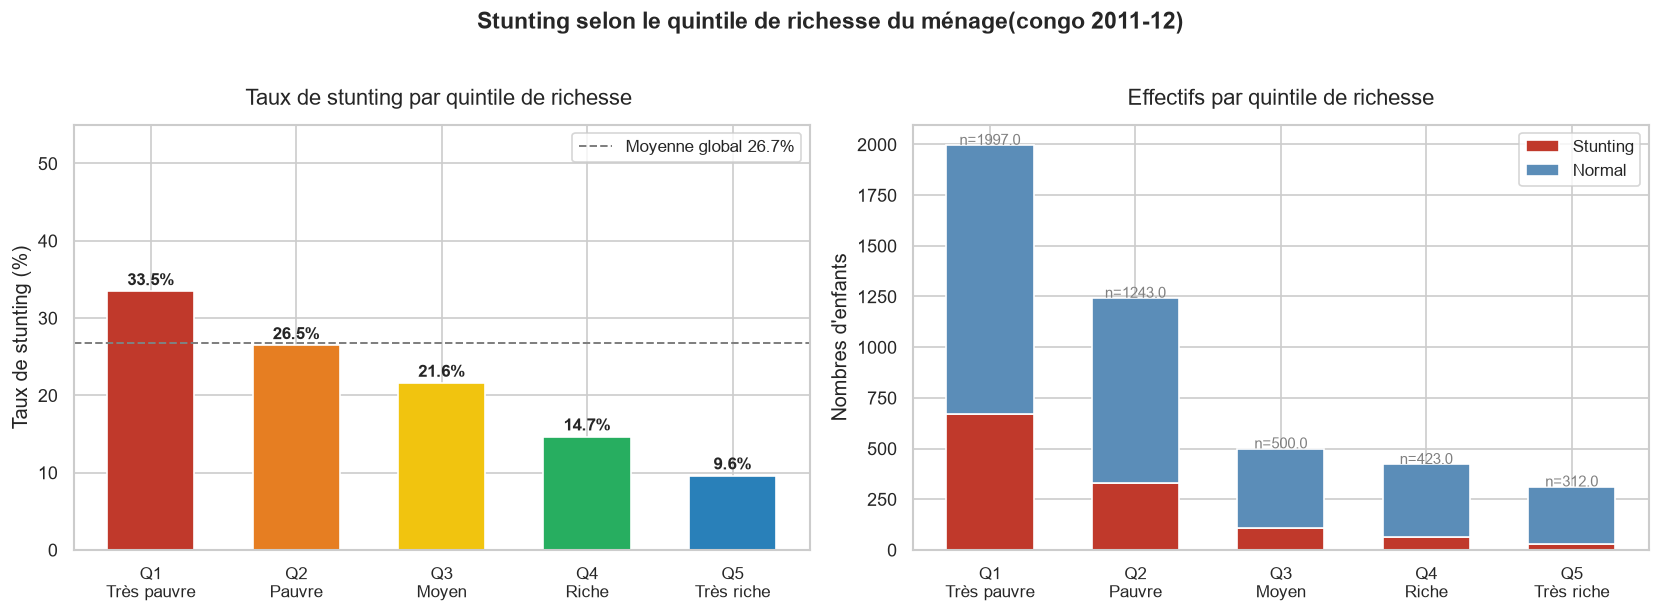

Graphique sauvegardé

=== Résumé numérique ====
                stunting  total  taux
hv270_label                          
Q1-très pauvre       668   1997  33.5
Q2-pauvre            329   1243  26.5
Q3-moyen             108    500  21.6
Q4-riche              62    423  14.7
Q5-très riche         30    312   9.6


In [7]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Ordre naturel des quintiles 
ordre_quintiles = ['Q1-très pauvre', 'Q2-pauvre', 'Q3-moyen', 'Q4-riche', 'Q5-très riche']

# Calcul des taux par quintile 
taux_richesse = (df.groupby("hv270_label")["stunting"].agg(["sum","count"])
                .rename(columns={"sum":"stunting","count":"total"}))

taux_richesse["taux"] = taux_richesse["stunting"] / taux_richesse["total"]*100
taux_richesse = taux_richesse.reindex(ordre_quintiles)

# Palette dégradée du rouge au bleu
colors_richesse = ['#C0392B', '#E67E22', '#F1C40F', '#27AE60', '#2980B9']

# Graphique gauche : taux par quintile
bar = axes[0].bar(
    range(len(ordre_quintiles)),
    taux_richesse["taux"],
    color= colors_richesse,
    width= 0.6,
    edgecolor="white"
)

axes[0].set_title("Taux de stunting par quintile de richesse ",fontsize=13,pad=12)
axes[0].set_ylabel("Taux de stunting (%)")
axes[0].set_ylim(0,55)
axes[0].set_xticks(range(len(ordre_quintiles)))
axes[0].set_xticklabels(["Q1\nTrès pauvre","Q2\nPauvre","Q3\nMoyen","Q4\nRiche","Q5\nTrès riche"],fontsize=10)

axes[0].axhline(
    y=df["stunting"].mean()*100,
    linestyle="--",linewidth=1.2,color="grey",
    label =f"Moyenne global {df["stunting"].mean()*100:.1f}%",
)
axes[0].legend(fontsize=10)
for i,taux in  enumerate(taux_richesse["taux"]):
    axes[0].text(i,taux+0.8,f"{taux:.1f}%",fontsize=10,ha="center",fontweight="bold")




# Graphique droite : effectifs par quintiles
axes[1].bar(
    range(len(ordre_quintiles)),taux_richesse["stunting"],
    color='#C0392B',edgecolor = "white",width=0.6,label="Stunting")

axes[1].bar(
    range(len(ordre_quintiles)),taux_richesse["total"]-taux_richesse["stunting"],
    color='#5B8DB8',edgecolor = "white",width=0.6,label="Normal",
    bottom = taux_richesse["stunting"]
    )

axes[1].set_title("Effectifs par quintile de richesse",fontsize=13,pad=12)
axes[1].set_ylabel("Nombres d'enfants")
axes[1].set_xticks(range(len(ordre_quintiles)))
axes[1].set_xticklabels(["Q1\nTrès pauvre","Q2\nPauvre","Q3\nMoyen","Q4\nRiche","Q5\nTrès riche"],fontsize=10)
axes[1].legend(fontsize=10)

for i,(idx,row) in enumerate(taux_richesse.iterrows()):
    axes[1].text(i,row["total"] +0.8,f"n={row["total"]}",fontsize=9,color="grey",ha='center')

fig.suptitle("Stunting selon le quintile de richesse du ménage(congo 2011-12)",
            fontsize=14, fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"03_stunting_richesse.png"),dpi=150,bbox_inches="tight")
plt.show()

print("Graphique sauvegardé")
print("\n=== Résumé numérique ====")
print(taux_richesse[["stunting","total","taux"]].round(1))








## 6. Stunting par accès à l'électricité et à l'eau potable

Le gradient de richesse est le facteur le plus discriminant
observé jusqu'ici (écart de 23.9 points entre Q1 et Q5),
devant le milieu de résidence (11.5 points).

On examine maintenant deux variables d'accès aux services
essentiels directement liées aux conditions de vie du ménage :
- hv206 : accès à l'électricité (0=non, 1=oui)
- hv201 : source d'eau potable (codes DHS multiples)

Pour hv201, on regroupe les codes en deux catégories :
eau améliorée (robinet, forage, source protégée)
vs eau non améliorée (surface, puits non protégé, etc.)
selon la classification standard OMS/UNICEF.

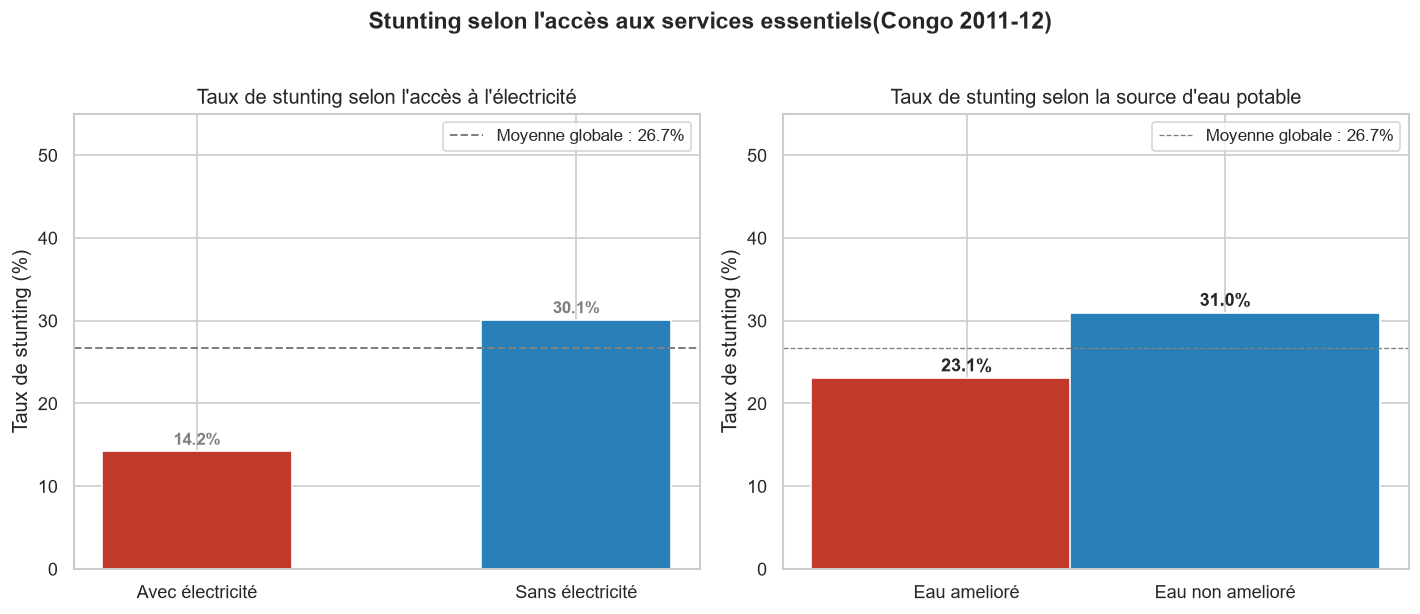

Graphique sauvegardé

=== Électricité ===
                  stunting  total  taux
hv206_label                            
Avec électricité       134    943  14.2
Sans électricité      1063   3531  30.1

=== Eau ===
                  stunting  total  taux
eau_label                              
Eau amelioré           554   2400  23.1
Eau non amelioré       643   2075  31.0


In [8]:
# Recodage hv201 
eau_amelioree = [11,12,13,14,21,31,41,51,71]

df["eau_label"]= df["hv201"].apply(
    lambda x:"Eau amelioré" if x in eau_amelioree else "Eau non amelioré"
)

# calcul de taux 
taux_electricite = (df[df["hv206_label"].notna()]
                    .groupby("hv206_label")["stunting"]
                    .agg(["sum","count"])
                    .rename(columns={"sum":"stunting","count":"total"}))
taux_electricite["taux"] = taux_electricite["stunting"]/taux_electricite["total"]*100

taux_eau = (df.groupby("eau_label")["stunting"]
            .agg(["sum","count"])
            .rename(columns={"sum":"stunting","count":"total"})
            )
taux_eau["taux"] = taux_eau["stunting"]/taux_eau["total"]*100


# Les graphiques
fig, axes = plt.subplots(1,2,figsize=(12,5))

# Graphiques de gauches : électricité
color_elec = ['#C0392B', '#2980B9']
axes[0].bar(
    taux_electricite.index,
    taux_electricite["taux"],
    color =color_elec,
    width=0.5, edgecolor="white"
)
axes[0].set_title("Taux de stunting selon l'accès à l'électricité")
axes[0].set_ylim(0,55)
axes[0].set_ylabel("Taux de stunting (%)")
axes[0].axhline(
    y=df["stunting"].mean()*100,
    linestyle ="--",linewidth  =1.2,color = "grey",label = f"Moyenne globale : {df["stunting"].mean()*100:.1f}%"
)
axes[0].legend(fontsize=10)
for i,(idx,row) in enumerate(taux_electricite.iterrows()):
    axes[0].text(i,row["taux"] +0.8,f"{row['taux']:.1f}%",fontsize=10,color="grey",fontweight="bold",ha="center")



# Graphique de droite : eau
color_eau = ['#C0392B', '#2980B9']
axes[1].bar(
    taux_eau.index,
    taux_eau["taux"],
    color=color_eau,width=1.2,edgecolor="white"
)
axes[1].set_title("Taux de stunting selon la source d'eau potable")
axes[1].set_ylim(0,55)
axes[1].set_ylabel("Taux de stunting (%)")
axes[1].axhline(
    y=df["stunting"].mean()*100,
    linestyle="--",color="grey",linewidth=0.8,
    label =f"Moyenne globale : {df["stunting"].mean()*100:.1f}%"
)
axes[1].legend(fontsize=10)
for i,(idx,row) in enumerate(taux_eau.iterrows()):
    axes[1].text(i,row["taux"]+0.8,f"{row["taux"]:.1f}%",fontsize=11,ha="center",fontweight="bold")

fig.suptitle(
    "Stunting selon l'accès aux services essentiels(Congo 2011-12)",
    fontsize=14,fontweight="bold",y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"04 stunting services.png"),
            dpi=150,bbox_inches="tight")
plt.show()
print("Graphique sauvegardé")
print("\n=== Électricité ===")
print(taux_electricite[["stunting","total","taux"]].round(1))
print("\n=== Eau ===")
print(taux_eau[["stunting","total","taux"]].round(1))

## 7. Stunting par sexe et âge de l'enfant

On examine maintenant les caractéristiques propres à l'enfant
pas au ménage. Deux questions :

1. Les garçons sont-ils plus touchés que les filles ?
   (hypothèse documentée dans la littérature DHS Afrique)
2. Le stunting augmente-t-il avec l'âge ? 
(le stunting est cumulatif, plus l'enfant grandit sans
   nutrition adéquate, plus l'écart avec la norme s'accumule)

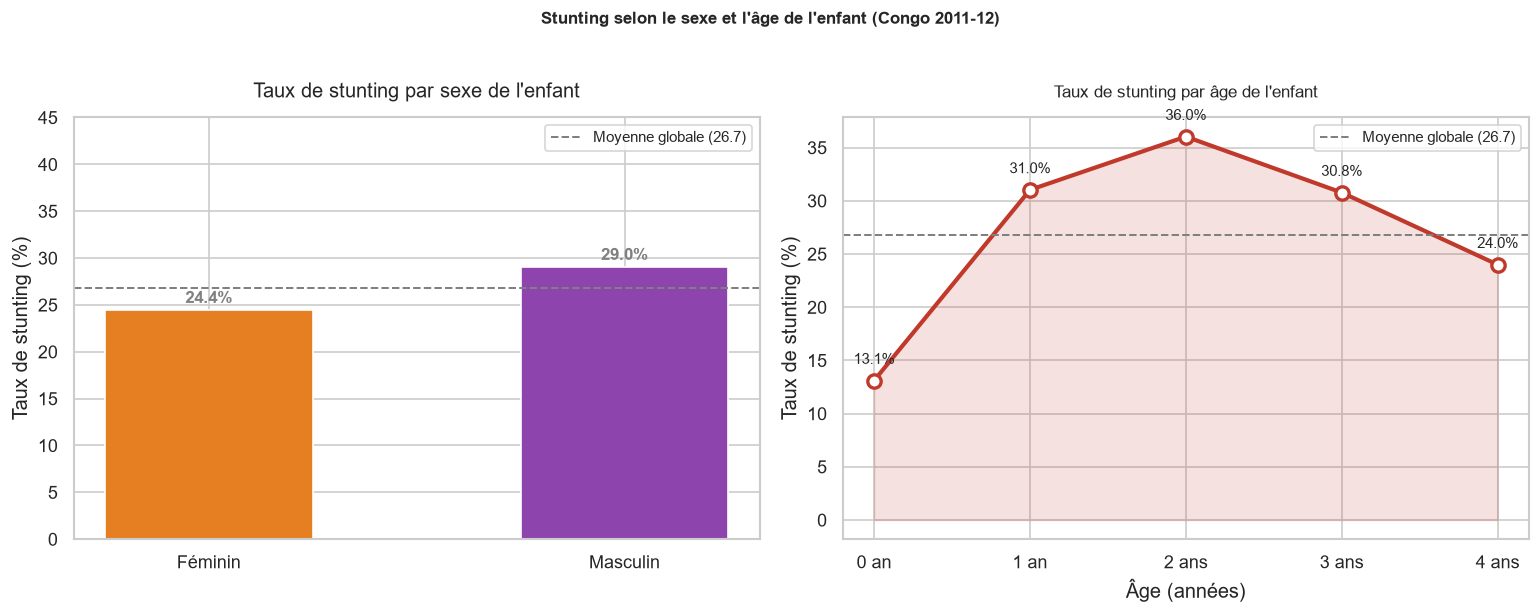

Graphique sauvegardé

=== Sexe ===
          stunting  total  taux
b4_label                       
Féminin        535   2192  24.4
Masculin       662   2283  29.0

=== Âge ===
     stunting  total  taux
b8                        
0.0       134   1023  13.1
1.0       304    980  31.0
2.0       312    866  36.0
3.0       280    910  30.8
4.0       167    696  24.0


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

# Graphiques de gauche : Stunting par sexe

taux_sexe = (df.groupby("b4_label")["stunting"]
            .agg(["sum","count"])
             .rename(columns={"sum":"stunting","count":"total"}))

taux_sexe["taux"]= taux_sexe["stunting"]/taux_sexe["total"]*100
colors_sexe = ['#E67E22', '#8E44AD']

axes[0].bar(
    taux_sexe.index,
    taux_sexe["taux"],
    color = colors_sexe, width =0.5,edgecolor="White"
)
axes[0].set_title("Taux de stunting par sexe de l\'enfant",
                  fontsize=12,pad=12)

axes[0].set_ylabel("Taux de stunting (%)")
axes[0].set_ylim(0,45)
axes[0].axhline(
    y=df["stunting"].mean()*100,
    color="grey",
    linestyle="--",linewidth=1.2,
    label=f"Moyenne globale ({df["stunting"].mean()*100:.1f})"
)
axes[0].legend(fontsize=9)
for i, (idx,row) in enumerate(taux_sexe.iterrows()):
    axes[0].text(i,row["taux"]+0.8,f"{row["taux"]:.1f}%",fontsize=10,ha="center",color="grey",fontweight="bold")


# Graphique de droite : Stunting par age
taux_age =(df.groupby("b8")["stunting"].agg(["sum","count"])
           .rename(columns={"sum":"stunting","count":"total"}))
taux_age["taux"] = taux_age["stunting"]/taux_age["total"]*100
taux_age = taux_age.sort_index()


axes[1].plot(
    taux_age.index,
    taux_age["taux"],
    color="#C0392B",linewidth=2.5,marker="o",
    markersize=8,markerfacecolor="white",markeredgecolor="#C0392B",markeredgewidth = 2
)
# zone colorée sous la courbe 
axes[1].fill_between(
    taux_age.index,
    taux_age["taux"],
    alpha=0.15,color="#C0392B"
)
axes[1].set_title("Taux de stunting par âge de l\'enfant",fontsize=10,pad=12)
axes[1].set_xlabel('Âge (années)')
axes[1].set_ylabel("Taux de stunting (%)")
axes[1].set_xticks([0,1,2,3,4])
axes[1].set_xticklabels(['0 an', '1 an', '2 ans', '3 ans', '4 ans'])

axes[1].axhline(
    y=df["stunting"].mean()*100,
    color="grey",linestyle="--",linewidth=1.2,
    label = f"Moyenne globale ({df["stunting"].mean()*100:.1f})"
)
axes[1].legend(fontsize=9)
for i, (age,row) in enumerate(taux_age.iterrows()):
    axes[1].annotate(
        f"{row["taux"]:.1f}%",
        xy=(age,row["taux"]),
        xytext=(0,10),
        textcoords ="offset points",
        ha="center",fontsize=9
    )
fig.suptitle("Stunting selon le sexe et l\'âge de l\'enfant (Congo 2011-12)",
             fontsize=10,fontweight ="bold",y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"05_stunting_sexe_age.png"),
            dpi=150,bbox_inches="tight")
plt.show()

print("Graphique sauvegardé")
print("\n=== Sexe ===")
print(taux_sexe[['stunting','total','taux']].round(1))
print("\n=== Âge ===")
print(taux_age[['stunting','total','taux']].round(1))




